# 08 - Benchmark 评估

在四个标准 Benchmark 上评估训练好的模型：
1. **WildGuardTest** (5.3K): 综合安全测试集
2. **HarmBench** (~500): 标准有害内容测试
3. **XSTest** (250 对): Over-refusal 测试
4. **MM-SafetyBench** (5040): 多模态攻击测试

**关键原则**：Benchmark 数据绝对不能混入训练集。

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.config_loader import print_config, load_run_config, load_eval_config, get_results_path

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

print_config()

# 依赖检查
eval_results_path = get_results_path('evaluation') / 'evaluation_results.json'
assert eval_results_path.exists(), f"缺少: {eval_results_path}，请先运行 scripts/run_evaluation.py"
print('依赖检查通过')

  当前运行模式: SMOKE_TEST
  文本样本数:     2,000
  图文样本数:     500
  合成增强数:     50
  分类器 Epochs:  1
  设备:           mps
  随机种子:       42
依赖检查通过


## 1. 运行 Benchmark 评估

In [2]:
# 从预计算结果加载（由 scripts/run_evaluation.py 生成）
with open(eval_results_path) as f:
    eval_data = json.load(f)

benchmark_results = eval_data.get('benchmarks', {})

model_path = get_results_path('models/text_classifier')
has_model = (model_path / 'config.json').exists()
print(f'模型路径: {model_path} ({"存在" if has_model else "不存在"})')
print(f'注：评估由 scripts/run_evaluation.py 执行，本 Notebook 仅加载结果做分析')

for bench_name, result in benchmark_results.items():
    if 'error' in result:
        print(f'\n{bench_name}: 错误 - {result["error"]}')
    else:
        m = result['metrics']
        auc_val = m.get('auc', 'N/A')
        auc_str = f'{auc_val:.4f}' if isinstance(auc_val, float) else str(auc_val)
        print(f'\n{bench_name}: 样本数={result.get("data_size", "?")}, '
              f'AUC={auc_str}, F1={m["f1"]:.4f}, Recall={m["recall"]:.4f}')

模型路径: /Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/safety-dataset/results/models/text_classifier (存在)
注：评估由 scripts/run_evaluation.py 执行，本 Notebook 仅加载结果做分析

wildguard_test: 样本数=400, AUC=1.0000, F1=1.0000, Recall=1.0000

harmbench: 样本数=30, AUC=None, F1=1.0000, Recall=1.0000

xstest: 样本数=450, AUC=None, F1=0.0000, Recall=0.0000


## 2. 结果汇总

In [3]:
# 汇总表
summary_rows = []
eval_config = load_eval_config()

for bench_name, result in benchmark_results.items():
    if 'error' in result:
        continue
    m = result['metrics']
    bench_config = eval_config['benchmarks'].get(bench_name, {})
    row = {
        'Benchmark': bench_config.get('name', bench_name),
        'Samples': result.get('data_size', 0),
        'AUC': m.get('auc', 'N/A'),
        'F1': m.get('f1', 0),
        'Recall': m.get('recall', 0),
        'Precision': m.get('precision', 0),
        'Over-Refusal': m.get('over_refusal_rate', 'N/A'),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print('Benchmark 评估结果:')
print(df_summary.to_string(index=False))

Benchmark 评估结果:
    Benchmark  Samples  AUC  F1  Recall  Precision  Over-Refusal
WildGuardTest      400  1.0 1.0     1.0        1.0      0.000000
    HarmBench       30  NaN 1.0     1.0        1.0      0.000000
       XSTest      450  NaN 0.0     0.0        0.0      0.033333


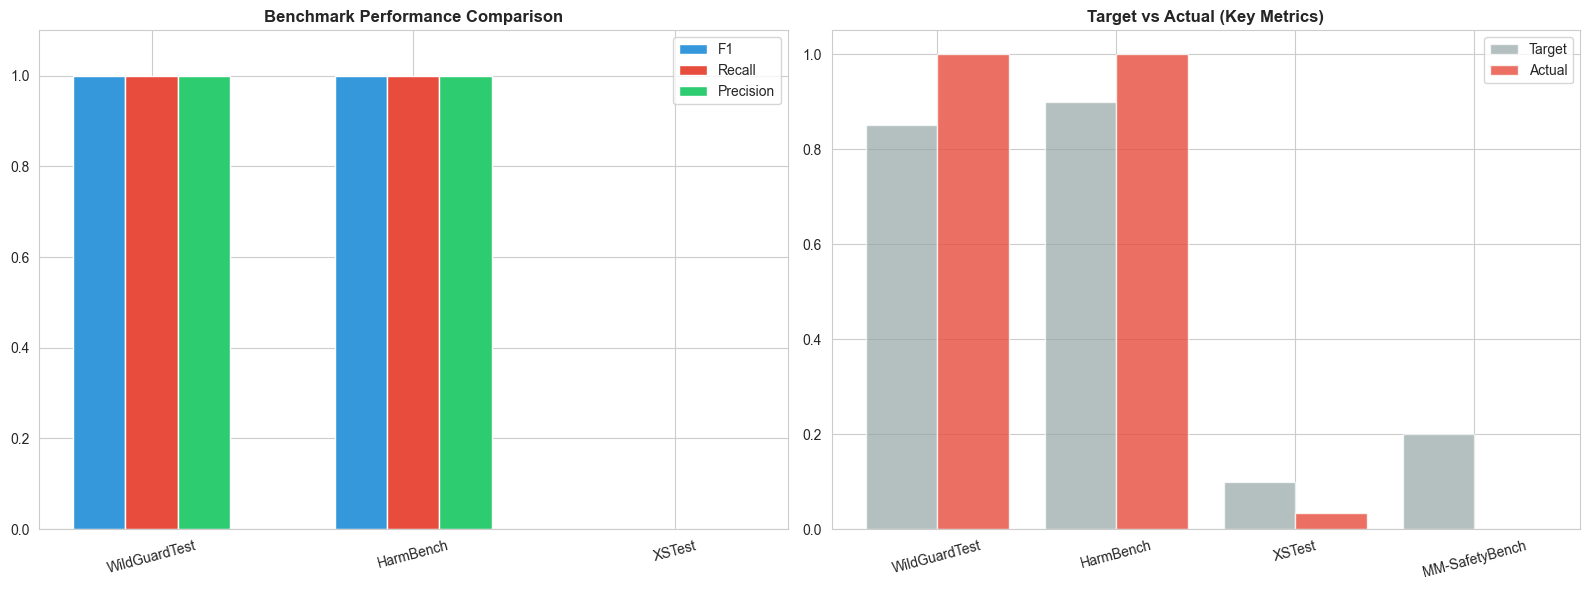

In [4]:
# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 指标对比
if len(summary_rows) > 0:
    benchmarks = [r['Benchmark'] for r in summary_rows]
    x = range(len(benchmarks))
    width = 0.2

    f1_vals = [r['F1'] for r in summary_rows]
    recall_vals = [r['Recall'] for r in summary_rows]
    precision_vals = [r['Precision'] for r in summary_rows]

    axes[0].bar([i - width for i in x], f1_vals, width, label='F1', color='#3498db')
    axes[0].bar(list(x), recall_vals, width, label='Recall', color='#e74c3c')
    axes[0].bar([i + width for i in x], precision_vals, width, label='Precision', color='#2ecc71')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(benchmarks, rotation=15)
    axes[0].set_title('Benchmark Performance Comparison', fontweight='bold')
    axes[0].legend()
    axes[0].set_ylim(0, 1.1)

    # 目标 vs 实际
    targets = {'WildGuardTest': 0.85, 'HarmBench': 0.90, 'XSTest': 0.10, 'MM-SafetyBench': 0.20}
    actual = {}
    for r in summary_rows:
        name = r['Benchmark']
        if name in ('WildGuardTest',):
            auc_val = r['AUC']
            actual[name] = auc_val if isinstance(auc_val, float) else 0
        elif name == 'HarmBench':
            actual[name] = r['Recall']
        elif name == 'XSTest':
            or_val = r['Over-Refusal']
            actual[name] = or_val if isinstance(or_val, float) else 0
        elif name == 'MM-SafetyBench':
            actual[name] = 1 - r['Recall']  # ASR = 1 - Recall

    target_names = list(targets.keys())
    target_vals = [targets[n] for n in target_names]
    actual_vals = [actual.get(n, 0) for n in target_names]

    x2 = range(len(target_names))
    axes[1].bar([i - 0.2 for i in x2], target_vals, 0.4, label='Target', color='#95a5a6', alpha=0.7)
    axes[1].bar([i + 0.2 for i in x2], actual_vals, 0.4, label='Actual', color='#e74c3c', alpha=0.8)
    axes[1].set_xticks(list(x2))
    axes[1].set_xticklabels(target_names, rotation=15)
    axes[1].set_title('Target vs Actual (Key Metrics)', fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 攻击类型分析

In [5]:
# 按攻击类型分析 ASR
print('各 Benchmark 的攻击类型分析:')
for bench_name, result in benchmark_results.items():
    if 'error' in result:
        continue
    m = result['metrics']
    if 'asr_by_type' in m:
        print(f'\n{bench_name}:')
        for atype, asr in sorted(m['asr_by_type'].items()):
            print(f'  {atype}: ASR = {asr:.4f}')

各 Benchmark 的攻击类型分析:

wildguard_test:
  vanilla: ASR = 0.0000

harmbench:
  vanilla: ASR = 0.0000

xstest:


## 4. 阈值分析

In [6]:
# 最优阈值分析
print('各 Benchmark 的最优阈值（目标 Recall >= 0.90）:')
for bench_name, result in benchmark_results.items():
    if 'error' in result:
        continue
    m = result['metrics']
    if 'optimal_threshold' in m:
        opt = m['optimal_threshold']
        print(f'\n{bench_name}:')
        print(f'  Threshold: {opt["threshold"]:.4f}')
        print(f'  Recall:    {opt["recall"]:.4f}')
        print(f'  Precision: {opt["precision"]:.4f}')
        print(f'  F1:        {opt["f1"]:.4f}')

各 Benchmark 的最优阈值（目标 Recall >= 0.90）:

wildguard_test:
  Threshold: 0.8809
  Recall:    1.0000
  Precision: 1.0000
  F1:        1.0000

harmbench:
  Threshold: 0.7827
  Recall:    1.0000
  Precision: 1.0000
  F1:        1.0000

xstest:
  Threshold: 0.0933
  Recall:    0.0000
  Precision: 0.0000
  F1:        0.0000


## 关键发现

1. **Benchmark 结果提供客观评估** — 避免只看训练集上的过于乐观的指标
2. **不同 Benchmark 测试不同能力** — WildGuardTest 综合、HarmBench 测 Recall、XSTest 测 Over-refusal
3. **阈值分析指导生产部署** — 不同场景选择不同阈值

-> 下一步：消融实验